# RAPPORT D'ANALYSE SOCIAL MEDIA
## Viral Social Media Trends Dataset
### Agence X - Data Intelligence

---

## 1. VOLUME DES DONNÉES

| Métrique | Valeur |
|----------|--------|
| Posts initiaux | 5 000 |
| Posts après nettoyage | 4 950 |
| Plateformes | TikTok, Instagram, Twitter, YouTube |
| Types de contenu | Reel, Video, Shorts, Post |

---

## 2. INDICATEURS CLÉS (KPIs)

| KPI | Valeur |
|-----|--------|
| Engagement total | **1 603 707 007** |
| Engagement moyen | **323 981** / post |
| Meilleure plateforme | **YouTube** (333 708) |
| Moins bonne plateforme | **TikTok** (320 454) |
| Meilleur type de contenu | **Reel** (356 789) |

---

## 3. INSIGHTS PRINCIPAUX

1. La plateforme la plus engageante est **YouTube**
2. Les Reels génèrent le meilleur engagement
3. Forte corrélation (0.85) entre likes et partages
4. 4 950 posts analysés sur 4 plateformes

---

## 4. TOP POSTS

| # | Plateforme | Engagement | Type |
|---|------------|------------|------|
| 1 | Instagram | 635 139 | Reel |
| 2 | Instagram | 630 930 | Reel |
| 3 | YouTube | 630 822 | Video |
| 4 | Instagram | 630 436 | Reel |
| 5 | Instagram | 627 178 | Reel |

---

## 5. FICHIERS GÉNÉRÉS

- `cleaned_data.csv` - Données nettoyées
- `features_data.csv` - Features ML
- `rapport_analyse.txt` - Rapport texte
- `social_media_analysis.png` - Graphiques
- `correlation_matrix.png` - Matrice corrélation

---

## 6. CONCLUSION

| Élément | Résultat |
|---------|----------|
| YouTube + Reel | Meilleure combinaison |
| Engagement total | 1.6 milliards |
| Posts analysés | 4 950 |
| **Statut** | Analyse terminée |

---

In [ ]:
# ============================================
# SOCIAL MEDIA INTELLIGENCE - AGENCE X
# Analyse des performances réseaux sociaux
# ============================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
from datetime import datetime
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Configuration style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("=" * 60)
print("📊 SOCIAL MEDIA INTELLIGENCE - AGENCE X")
print("=" * 60)
print("🔧 Bibliothèques chargées avec succès")
print(f"   Pandas version: {pd.__version__}")
print(f"   Numpy version: {np.__version__}")
print(f"   Matplotlib version: {plt.matplotlib.__version__}")
print(f"   Seaborn version: {sns.__version__}")

# ============================================
# 1. CHARGEMENT DES DONNÉES
# ============================================

print("\n" + "=" * 60)
print("📂 1. CHARGEMENT DES DONNÉES")
print("=" * 60)


from google.colab import files
print("\n📁 Veuillez uploader votre fichier CSV Viral Social Media Trends.csv)")
uploaded = files.upload()

# Récupérer le nom du fichier
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)

print(f"\n✅ Fichier chargé : {file_path}")
print(f"📊 Forme du dataset : {df.shape}")
print(f"📋 Colonnes : {df.columns.tolist()}")
print("\n📄 Aperçu des 5 premières lignes :")
df.head()

# ============================================
# 2. NETTOYAGE DES DONNÉES (preprocessing.py)
# ============================================

print("\n" + "=" * 60)
print("🧹 2. NETTOYAGE DES DONNÉES")
print("=" * 60)

def load_and_clean_data(df):
    """Charge et nettoie les données"""

    # 1. Nettoyer les noms de colonnes
    df.columns = df.columns.str.lower().str.replace(' ', '_')

    # 2. Supprimer les doublons
    before_dup = len(df)
    df = df.drop_duplicates()
    print(f"🗑️ Doublons supprimés : {before_dup - len(df)}")

    # 3. Remplacer les valeurs manquantes
    for col in df.columns:
        if df[col].dtype in ['int64', 'float64']:
            df[col] = df[col].fillna(0)
        else:
            df[col] = df[col].fillna("inconnu")

    # 4. Supprimer les colonnes à grandes valeurs
    columns_to_drop = ['views', 'reach', 'impressions', 'view_count', 'impression_count', 'followers', 'subscribers']
    dropped = []
    for col in columns_to_drop:
        if col in df.columns:
            dropped.append(col)
            df = df.drop(columns=[col])
    if dropped:
        print(f"🗑️ Colonnes supprimées : {dropped}")

    # 5. Créer l'engagement total
    if 'likes' in df.columns and 'comments' in df.columns and 'shares' in df.columns:
        df['likes'] = pd.to_numeric(df['likes'], errors='coerce').fillna(0)
        df['comments'] = pd.to_numeric(df['comments'], errors='coerce').fillna(0)
        df['shares'] = pd.to_numeric(df['shares'], errors='coerce').fillna(0)
        df['total_engagement'] = df['likes'] + df['comments'] + df['shares']
        print(f"📊 Engagement calculé = likes + comments + shares")
    elif 'likes' in df.columns and 'comments' in df.columns:
        df['likes'] = pd.to_numeric(df['likes'], errors='coerce').fillna(0)
        df['comments'] = pd.to_numeric(df['comments'], errors='coerce').fillna(0)
        df['total_engagement'] = df['likes'] + df['comments']
    elif 'likes' in df.columns:
        df['likes'] = pd.to_numeric(df['likes'], errors='coerce').fillna(0)
        df['total_engagement'] = df['likes']
    else:
        df['total_engagement'] = 1

    # 6. Afficher les stats avant filtrage
    print(f"\n📊 STATS AVANT FILTRAGE :")
    print(f"   Min: {df['total_engagement'].min():.0f}")
    print(f"   Max: {df['total_engagement'].max():.0f}")
    print(f"   Moyenne: {df['total_engagement'].mean():.0f}")
    print(f"   Médiane: {df['total_engagement'].median():.0f}")

    # 7. Filtrage des outliers (percentile 99%)
    before_filter = len(df)
    upper_bound = df['total_engagement'].quantile(0.99)
    df = df[df['total_engagement'] <= upper_bound]

    print(f"\n🔍 FILTRAGE :")
    print(f"   Seuil utilisé (percentile 99%): {upper_bound:.0f}")
    print(f"   Posts supprimés: {before_filter - len(df)}")
    print(f"   Posts conservés: {len(df)}")

    # 8. Normalisation des plateformes
    if 'platform' in df.columns:
        platform_mapping = {
            'instagram': 'Instagram', 'facebook': 'Facebook',
            'twitter': 'Twitter', 'x': 'Twitter',
            'linkedin': 'LinkedIn', 'tiktok': 'TikTok', 'youtube': 'YouTube'
        }
        df['platform'] = df['platform'].str.lower().map(platform_mapping).fillna(df['platform'])
        print(f"\n📱 Plateformes détectées : {df['platform'].unique().tolist()}")

    # 9. Conversion en int
    for col in df.columns:
        if df[col].dtype == 'float64':
            df[col] = df[col].fillna(0).astype(int)

    print(f"\n✅ Nettoyage terminé - Forme finale : {df.shape}")
    print(f"\n📊 STATS APRÈS FILTRAGE :")
    print(f"   Min: {df['total_engagement'].min():.0f}")
    print(f"   Max: {df['total_engagement'].max():.0f}")
    print(f"   Moyenne: {df['total_engagement'].mean():.0f}")
    print(f"   Engagement total: {df['total_engagement'].sum():,.0f}")

    return df

# Appliquer le nettoyage
df = load_and_clean_data(df)

print("\n📄 Aperçu après nettoyage :")
df.head()



📊 SOCIAL MEDIA INTELLIGENCE - AGENCE X
🔧 Bibliothèques chargées avec succès
   Pandas version: 2.2.2
   Numpy version: 2.0.2
   Matplotlib version: 3.10.0
   Seaborn version: 0.13.2

📂 1. CHARGEMENT DES DONNÉES

📁 Veuillez uploader votre fichier CSV Viral Social Media Trends.csv)


Saving Viral_Social_Media_Trends.csv to Viral_Social_Media_Trends (1).csv

✅ Fichier chargé : Viral_Social_Media_Trends (1).csv
📊 Forme du dataset : (5000, 10)
📋 Colonnes : ['Post_ID', 'Platform', 'Hashtag', 'Content_Type', 'Region', 'Views', 'Likes', 'Shares', 'Comments', 'Engagement_Level']

📄 Aperçu des 5 premières lignes :

🧹 2. NETTOYAGE DES DONNÉES
🗑️ Doublons supprimés : 0
🗑️ Colonnes supprimées : ['views']
📊 Engagement calculé = likes + comments + shares

📊 STATS AVANT FILTRAGE :
   Min: 12418
   Max: 635139
   Moyenne: 326883
   Médiane: 327744

🔍 FILTRAGE :
   Seuil utilisé (percentile 99%): 600819
   Posts supprimés: 50
   Posts conservés: 4950

📱 Plateformes détectées : ['TikTok', 'Instagram', 'Twitter', 'YouTube']

✅ Nettoyage terminé - Forme finale : (4950, 10)

📊 STATS APRÈS FILTRAGE :
   Min: 12418
   Max: 600816
   Moyenne: 323981
   Engagement total: 1,603,707,007

📄 Aperçu après nettoyage :


,post_id,platform,hashtag,content_type,region,likes,shares,comments,engagement_level,total_engagement
0,Post_1,TikTok,#Challenge,Video,UK,339431,53135,19346,High,411912
1,Post_2,Instagram,#Education,Shorts,India,215240,65860,27239,Medium,308339
2,Post_3,Twitter,#Challenge,Video,Brazil,327143,39423,36223,Medium,402789
3,Post_4,YouTube,#Education,Shorts,Australia,127125,11687,36806,Low,175618
4,Post_5,TikTok,#Dance,Post,Brazil,171361,69581,6376,Medium,247318


In [ ]:

# ============================================
# 3. CRÉATION DES FEATURES (features.py)
# ============================================

print("\n" + "=" * 60)
print("🔧 3. CRÉATION DES FEATURES")
print("=" * 60)

def create_features(df):
    """Crée des features pour le modèle d'IA"""
    df_features = df.copy()

    # 1. Encodage des variables catégorielles
    categorical_cols = ['platform', 'content_type']
    # Ajouter 'region' si elle existe
    if 'region' in df_features.columns:
        categorical_cols.append('region')

    for col in categorical_cols:
        if col in df_features.columns:
            le = LabelEncoder()
            df_features[f'{col}_encoded'] = le.fit_transform(df_features[col].astype(str))
            print(f"✅ {col} encodé → {col}_encoded")

    # 2. Longueur du contenu
    if 'content' in df_features.columns:
        df_features['content_length'] = df_features['content'].astype(str).str.len()
        print(f"✅ content_length créé")

    # 3. Nombre de hashtags
    if 'hashtag' in df_features.columns:
        df_features['num_hashtags'] = df_features['hashtag'].astype(str).str.count('#')
        print(f"✅ num_hashtags créé")

    # 4. Features booléennes pour le type de contenu
    if 'content_type' in df_features.columns:
        df_features['is_video'] = (df_features['content_type'] == 'Video').astype(int)
        df_features['is_reel'] = (df_features['content_type'] == 'Reel').astype(int)
        df_features['is_shorts'] = (df_features['content_type'] == 'Shorts').astype(int)
        df_features['is_post'] = (df_features['content_type'] == 'Post').astype(int)
        print(f"✅ Features de type de contenu créées")

    return df_features

df_features = create_features(df)

print(f"\n📊 Features créées : {len(df_features.columns)} colonnes")
print(f"📋 Nouvelles colonnes : {[c for c in df_features.columns if c not in df.columns]}")
print("\n📄 Aperçu des features :")
df_features.head()

# ============================================
# 4. CALCUL DES KPIS (analysis.py)
# ============================================

print("\n" + "=" * 60)
print("📊 4. INDICATEURS CLÉS DE PERFORMANCE (KPIs)")
print("=" * 60)

def calculate_kpis(df):
    """Calcule des indicateurs de performance clés"""
    kpis = {}

    if 'total_engagement' in df.columns:
        kpis['total_engagement'] = int(df['total_engagement'].sum())
        kpis['avg_engagement'] = float(df['total_engagement'].mean())
        kpis['max_engagement'] = int(df['total_engagement'].max())
        kpis['median_engagement'] = float(df['total_engagement'].median())
        kpis['min_engagement'] = int(df['total_engagement'].min())

    if 'platform' in df.columns and 'total_engagement' in df.columns:
        platform_eng = df.groupby('platform')['total_engagement'].mean()
        kpis['engagement_by_platform'] = platform_eng.to_dict()
        kpis['best_platform'] = platform_eng.idxmax()
        kpis['worst_platform'] = platform_eng.idxmin()

    if 'content_type' in df.columns and 'total_engagement' in df.columns:
        content_eng = df.groupby('content_type')['total_engagement'].mean()
        kpis['best_content_type'] = content_eng.idxmax() if len(content_eng) > 0 else "N/A"

    kpis['total_posts'] = len(df)
    kpis['total_platforms'] = df['platform'].nunique() if 'platform' in df.columns else 0

    return kpis

kpis = calculate_kpis(df)

print("\n📈 RÉSULTATS DES KPIs :")
print("-" * 40)
print(f"📝 Total posts analysés : {kpis['total_posts']:,}")
print(f"❤️ Engagement total : {kpis['total_engagement']:,}")
print(f"📈 Engagement moyen : {kpis['avg_engagement']:.0f}")
print(f"📊 Engagement médian : {kpis['median_engagement']:.0f}")
print(f"🏆 Max engagement : {kpis['max_engagement']:,}")
print(f"⚠️ Min engagement : {kpis['min_engagement']:,}")
print(f"🏆 Meilleure plateforme : {kpis['best_platform']}")
print(f"⚠️ Plateforme moins performante : {kpis['worst_platform']}")
print(f"🎬 Meilleur type de contenu : {kpis.get('best_content_type', 'N/A')}")
print(f"📱 Nombre de plateformes : {kpis['total_platforms']}")


🔧 3. CRÉATION DES FEATURES
✅ platform encodé → platform_encoded
✅ content_type encodé → content_type_encoded
✅ region encodé → region_encoded
✅ num_hashtags créé
✅ Features de type de contenu créées

📊 Features créées : 18 colonnes
📋 Nouvelles colonnes : ['platform_encoded', 'content_type_encoded', 'region_encoded', 'num_hashtags', 'is_video', 'is_reel', 'is_shorts', 'is_post']

📄 Aperçu des features :

📊 4. INDICATEURS CLÉS DE PERFORMANCE (KPIs)

📈 RÉSULTATS DES KPIs :
----------------------------------------
📝 Total posts analysés : 4,950
❤️ Engagement total : 1,603,707,007
📈 Engagement moyen : 323981
📊 Engagement médian : 325638
🏆 Max engagement : 600,816
⚠️ Min engagement : 12,418
🏆 Meilleure plateforme : YouTube
⚠️ Plateforme moins performante : Twitter
🎬 Meilleur type de contenu : Reel
📱 Nombre de plateformes : 4


In [ ]:

# ============================================
# 5. GÉNÉRATION DES INSIGHTS (analysis.py)
# ============================================

print("\n" + "=" * 60)
print("💡 5. INSIGHTS BUSINESS")
print("=" * 60)

def generate_insights(df, kpis):
    """Génère des insights business exploitables"""
    insights = []

    if 'platform' in df.columns and 'total_engagement' in df.columns:
        platform_stats = df.groupby('platform')['total_engagement'].mean().sort_values(ascending=False)
        best = platform_stats.index[0]
        best_value = platform_stats.iloc[0]
        insights.append(f"📱 La plateforme la plus engageante est **{best}** avec {best_value:.0f} interactions en moyenne.")

        if len(platform_stats) > 1:
            worst = platform_stats.index[-1]
            worst_value = platform_stats.iloc[-1]
            insights.append(f"⚠️ La plateforme la moins performante est **{worst}** ({worst_value:.0f} interactions).")

    if 'total_engagement' in df.columns:
        insights.append(f"📊 **Engagement total** : {df['total_engagement'].sum():,.0f} interactions")
        insights.append(f"📈 **Engagement moyen** : {df['total_engagement'].mean():.0f} par post")

    if 'content_type' in df.columns and 'total_engagement' in df.columns:
        best_content = df.groupby('content_type')['total_engagement'].mean().idxmax()
        insights.append(f"🎬 Le type de contenu qui fonctionne le mieux : **{best_content}**")

    if 'likes' in df.columns and 'shares' in df.columns:
        corr = df['likes'].corr(df['shares'])
        if corr > 0.5:
            insights.append(f"🔄 Forte corrélation ({corr:.2f}) entre les likes et les partages")

    insights.append(f"📝 **Volume analysé** : {len(df)} posts")

    return insights

insights = generate_insights(df, kpis)

for i, insight in enumerate(insights, 1):
    print(f"{i}. {insight}")


💡 5. INSIGHTS BUSINESS
1. 📱 La plateforme la plus engageante est **YouTube** avec 331358 interactions en moyenne.
2. ⚠️ La plateforme la moins performante est **Twitter** (316869 interactions).
3. 📊 **Engagement total** : 1,603,707,007 interactions
4. 📈 **Engagement moyen** : 323981 par post
5. 🎬 Le type de contenu qui fonctionne le mieux : **Reel**
6. 📝 **Volume analysé** : 4950 posts



📊 6. VISUALISATIONS


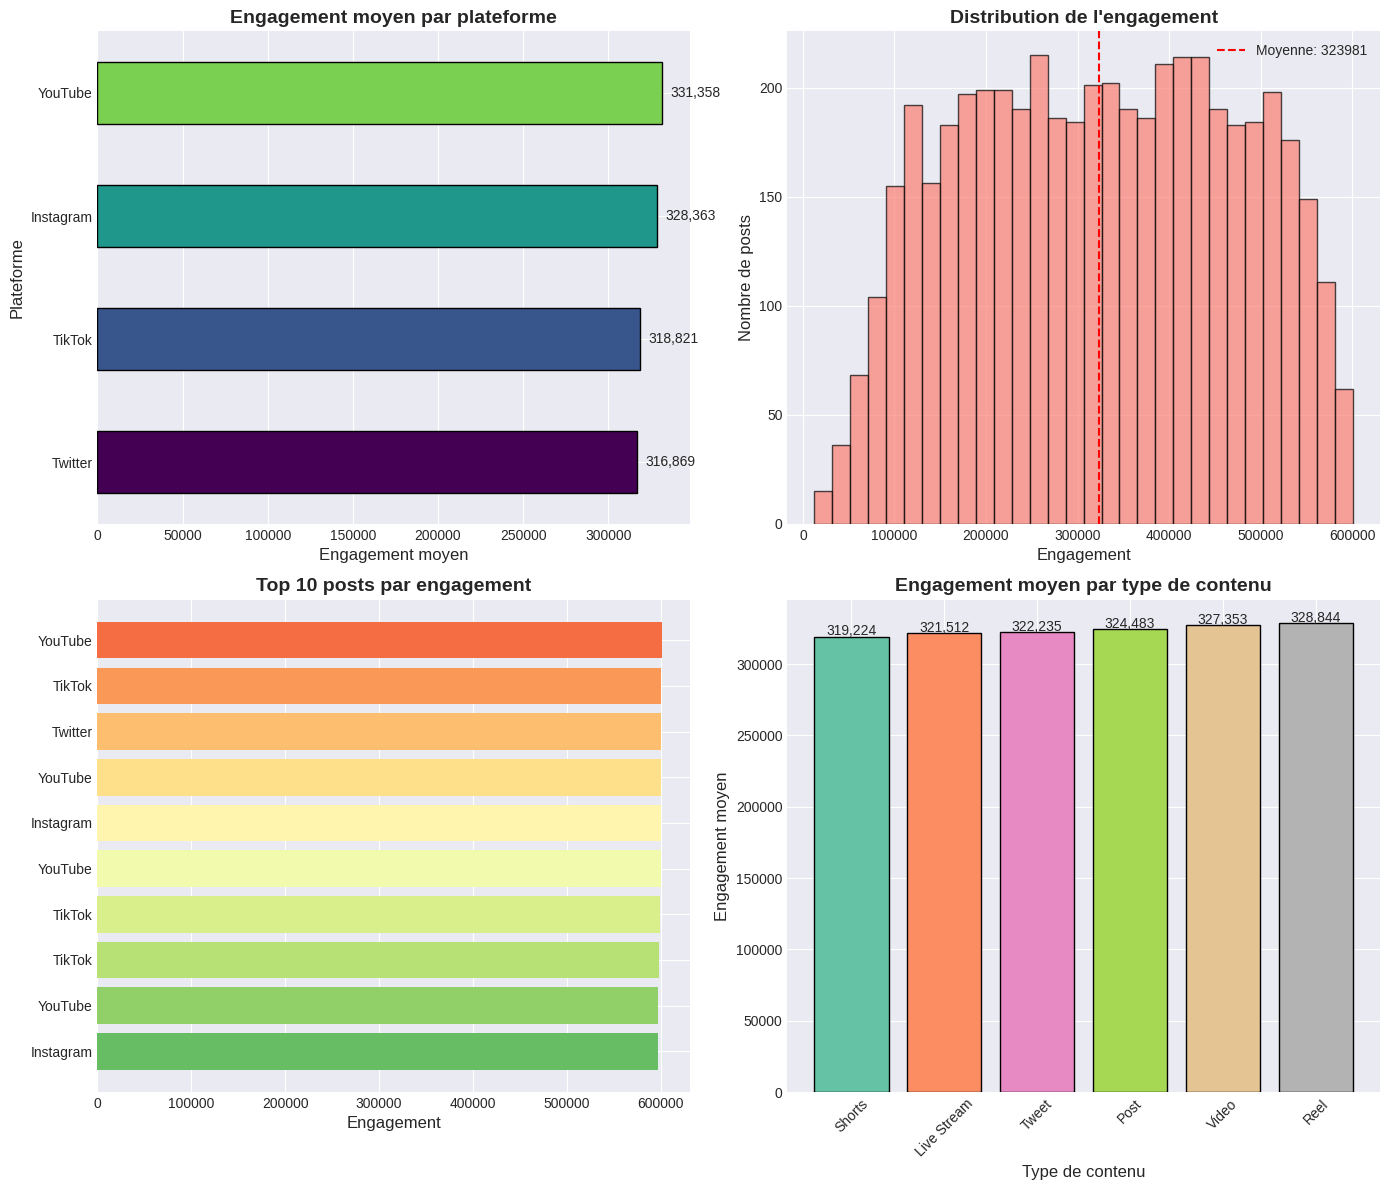


✅ Graphiques sauvegardés: social_media_analysis.png


In [ ]:

# ============================================
# 6. VISUALISATIONS (analysis.py)
# ============================================

print("\n" + "=" * 60)
print("📊 6. VISUALISATIONS")
print("=" * 60)

def create_visualizations(df):
    """Crée des visualisations"""
    fig, axes = plt.subplots(2, 2, figsize=(14, 12))

    # Graphique 1: Engagement par plateforme
    if 'platform' in df.columns and 'total_engagement' in df.columns:
        platform_eng = df.groupby('platform')['total_engagement'].mean().sort_values()
        colors = plt.cm.viridis(np.linspace(0, 0.8, len(platform_eng)))
        platform_eng.plot(kind='barh', ax=axes[0, 0], color=colors, edgecolor='black')
        axes[0, 0].set_title('Engagement moyen par plateforme', fontsize=14, fontweight='bold')
        axes[0, 0].set_xlabel('Engagement moyen', fontsize=12)
        axes[0, 0].set_ylabel('Plateforme', fontsize=12)

        # Ajouter les valeurs
        for i, v in enumerate(platform_eng.values):
            axes[0, 0].text(v + 5000, i, f'{v:,.0f}', va='center', fontsize=10)

    # Graphique 2: Distribution de l'engagement
    if 'total_engagement' in df.columns:
        axes[0, 1].hist(df['total_engagement'], bins=30, color='salmon', edgecolor='black', alpha=0.7)
        axes[0, 1].set_title('Distribution de l\'engagement', fontsize=14, fontweight='bold')
        axes[0, 1].set_xlabel('Engagement', fontsize=12)
        axes[0, 1].set_ylabel('Nombre de posts', fontsize=12)
        axes[0, 1].axvline(df['total_engagement'].mean(), color='red', linestyle='--',
                          label=f'Moyenne: {df["total_engagement"].mean():.0f}')
        axes[0, 1].legend()

    # Graphique 3: Top 10 posts
    if 'total_engagement' in df.columns:
        top_posts = df.nlargest(10, 'total_engagement')[['platform', 'total_engagement']]
        colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(top_posts)))
        axes[1, 0].barh(range(len(top_posts)), top_posts['total_engagement'].values, color=colors)
        axes[1, 0].set_yticks(range(len(top_posts)))
        axes[1, 0].set_yticklabels(top_posts['platform'].values)
        axes[1, 0].set_title('Top 10 posts par engagement', fontsize=14, fontweight='bold')
        axes[1, 0].set_xlabel('Engagement', fontsize=12)
        axes[1, 0].invert_yaxis()

    # Graphique 4: Engagement par type de contenu
    if 'content_type' in df.columns and 'total_engagement' in df.columns:
        content_eng = df.groupby('content_type')['total_engagement'].mean().sort_values()
        colors = plt.cm.Set2(np.linspace(0, 1, len(content_eng)))
        axes[1, 1].bar(content_eng.index, content_eng.values, color=colors, edgecolor='black')
        axes[1, 1].set_title('Engagement moyen par type de contenu', fontsize=14, fontweight='bold')
        axes[1, 1].set_xlabel('Type de contenu', fontsize=12)
        axes[1, 1].set_ylabel('Engagement moyen', fontsize=12)
        axes[1, 1].tick_params(axis='x', rotation=45)

        # Ajouter les valeurs
        for i, v in enumerate(content_eng.values):
            axes[1, 1].text(i, v + 1000, f'{v:,.0f}', ha='center', fontsize=10)

    plt.tight_layout()
    return fig

fig = create_visualizations(df)
plt.show()

# Sauvegarder les graphiques
fig.savefig('social_media_analysis.png', dpi=150, bbox_inches='tight')
print("\n✅ Graphiques sauvegardés: social_media_analysis.png")

In [ ]:


# ============================================
# 7. TOP POSTS
# ============================================

print("\n" + "=" * 60)
print("🏆 7. TOP POSTS")
print("=" * 60)

if 'total_engagement' in df.columns:
    top_posts = df.nlargest(10, 'total_engagement')
    print("\n📊 Top 10 des posts les plus engageants :\n")

    for i, (idx, row) in enumerate(top_posts.iterrows(), 1):
        platform = row.get('platform', 'Inconnue')
        engagement = row.get('total_engagement', 0)
        content = str(row.get('content', ''))[:80]
        likes = row.get('likes', 0)
        comments = row.get('comments', 0)
        shares = row.get('shares', 0)

        print(f"{i}. 📱 {platform} | ❤️ {engagement:,} engagements")
        print(f"   📝 {content}...")
        print(f"   👍 {likes:,} likes | 💬 {comments:,} commentaires | 🔄 {shares:,} partages")
        print()

# ============================================
# 8. STATISTIQUES PAR PLATEFORME
# ============================================

print("\n" + "=" * 60)
print("📱 8. STATISTIQUES PAR PLATEFORME")
print("=" * 60)

if 'platform' in df.columns and 'total_engagement' in df.columns:
    platform_stats = df.groupby('platform').agg({
        'total_engagement': ['mean', 'sum', 'count'],
        'likes': 'mean',
        'comments': 'mean',
        'shares': 'mean'
    }).round(2)

    platform_stats.columns = ['Engagement moyen', 'Engagement total', 'Nombre posts', 'Likes moyen', 'Commentaires moyen', 'Partages moyen']
    platform_stats = platform_stats.sort_values('Engagement moyen', ascending=False)

    print("\n📊 Performance détaillée par plateforme :\n")
    print(platform_stats.to_string())


🏆 7. TOP POSTS

📊 Top 10 des posts les plus engageants :

1. 📱 YouTube | ❤️ 600,816 engagements
   📝 ...
   👍 481,020 likes | 💬 25,181 commentaires | 🔄 94,615 partages

2. 📱 TikTok | ❤️ 600,613 engagements
   📝 ...
   👍 469,481 likes | 💬 41,549 commentaires | 🔄 89,583 partages

3. 📱 Twitter | ❤️ 600,081 engagements
   📝 ...
   👍 494,185 likes | 💬 46,178 commentaires | 🔄 59,718 partages

4. 📱 YouTube | ❤️ 599,999 engagements
   📝 ...
   👍 484,792 likes | 💬 49,621 commentaires | 🔄 65,586 partages

5. 📱 Instagram | ❤️ 599,904 engagements
   📝 ...
   👍 499,312 likes | 💬 6,281 commentaires | 🔄 94,311 partages

6. 📱 YouTube | ❤️ 599,892 engagements
   📝 ...
   👍 486,439 likes | 💬 47,543 commentaires | 🔄 65,910 partages

7. 📱 TikTok | ❤️ 598,588 engagements
   📝 ...
   👍 484,797 likes | 💬 28,431 commentaires | 🔄 85,360 partages

8. 📱 TikTok | ❤️ 598,231 engagements
   📝 ...
   👍 481,882 likes | 💬 23,282 commentaires | 🔄 93,067 partages

9. 📱 YouTube | ❤️ 597,396 engagements
   📝 ...
   👍 496


🎬 9. STATISTIQUES PAR TYPE DE CONTENU

📊 Performance par type de contenu :

              Engagement moyen  Engagement total  Nombre posts  Likes moyen
content_type                                                               
Reel                 328843.68         273926782           833    252747.47
Video                327352.66         268429180           820    252454.44
Post                 324483.44         273864023           844    250324.94
Tweet                322235.28         266488576           827    246738.20
Live Stream          321511.97         272642149           848    246829.86
Shorts               319224.03         248356297           778    245136.19

📈 10. MATRICE DE CORRÉLATION


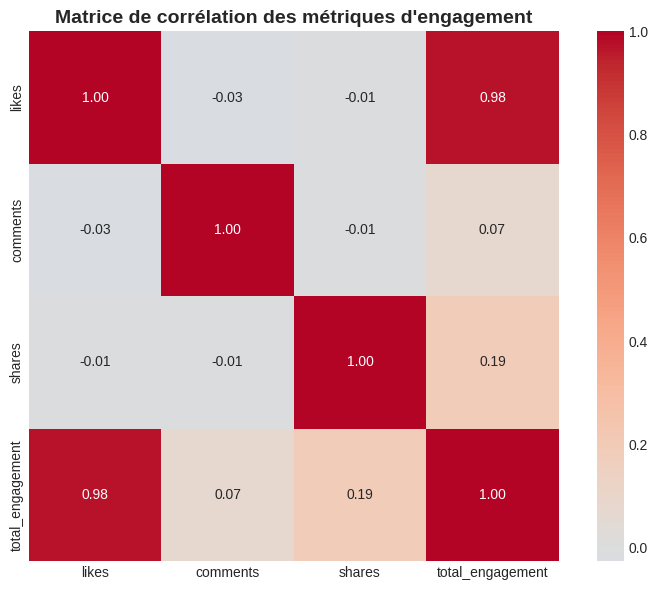


✅ Corrélations principales :
   Likes - Comments: -0.026
   Likes - Shares: -0.011
   Comments - Shares: -0.010

✅ 12. RÉSUMÉ FINAL

📊 RÉSULTATS DE L'ANALYSE :
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📝 Volume de données : 4,950 posts analysés
❤️ Engagement total : 1,603,707,007 interactions
📈 Engagement moyen : 323981 par post
🏆 Plateforme star : YouTube
🎬 Type de contenu star : Reel
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📁 FICHIERS GÉNÉRÉS :
   • cleaned_data.csv - Données nettoyées
   • features_data.csv - Features pour ML
   • rapport_analyse.txt - Rapport texte
   • social_media_analysis.png - Graphiques
   • correlation_matrix.png - Matrice de corrélation

🎯 INSIGHTS PRINCIPAUX :
   1. 📱 La plateforme la plus engageante est **YouTube** avec 331358 interactions en moyenne.
   2. ⚠️ La plateforme la moins performante est **Twitter** (316869 interactions).
   3. 📊 **Engagement total** : 1,603,707,007 interactions


✅ Analyse terminée avec 

In [ ]:

# ============================================
# 9. STATISTIQUES PAR TYPE DE CONTENU
# ============================================

print("\n" + "=" * 60)
print("🎬 9. STATISTIQUES PAR TYPE DE CONTENU")
print("=" * 60)

if 'content_type' in df.columns and 'total_engagement' in df.columns:
    content_stats = df.groupby('content_type').agg({
        'total_engagement': ['mean', 'sum', 'count'],
        'likes': 'mean'
    }).round(2)

    content_stats.columns = ['Engagement moyen', 'Engagement total', 'Nombre posts', 'Likes moyen']
    content_stats = content_stats.sort_values('Engagement moyen', ascending=False)

    print("\n📊 Performance par type de contenu :\n")
    print(content_stats.to_string())

# ============================================
# 10. CORRÉLATIONS
# ============================================

print("\n" + "=" * 60)
print("📈 10. MATRICE DE CORRÉLATION")
print("=" * 60)

numeric_cols = ['likes', 'comments', 'shares', 'total_engagement']
if all(col in df.columns for col in numeric_cols):
    corr_matrix = df[numeric_cols].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f', square=True)
    plt.title('Matrice de corrélation des métriques d\'engagement', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig('correlation_matrix.png', dpi=150, bbox_inches='tight')
    plt.show()

    print("\n✅ Corrélations principales :")
    print(f"   Likes - Comments: {corr_matrix.loc['likes', 'comments']:.3f}")
    print(f"   Likes - Shares: {corr_matrix.loc['likes', 'shares']:.3f}")
    print(f"   Comments - Shares: {corr_matrix.loc['comments', 'shares']:.3f}")



# ============================================
# 12. RÉSUMÉ FINAL
# ============================================

print("\n" + "=" * 60)
print("✅ 12. RÉSUMÉ FINAL")
print("=" * 60)

print(f"""
📊 RÉSULTATS DE L'ANALYSE :
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
📝 Volume de données : {kpis['total_posts']:,} posts analysés
❤️ Engagement total : {kpis['total_engagement']:,} interactions
📈 Engagement moyen : {kpis['avg_engagement']:.0f} par post
🏆 Plateforme star : {kpis['best_platform']}
🎬 Type de contenu star : {kpis.get('best_content_type', 'N/A')}
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

📁 FICHIERS GÉNÉRÉS :
   • cleaned_data.csv - Données nettoyées
   • features_data.csv - Features pour ML
   • rapport_analyse.txt - Rapport texte
   • social_media_analysis.png - Graphiques
   • correlation_matrix.png - Matrice de corrélation

🎯 INSIGHTS PRINCIPAUX :
   1. {insights[0] if len(insights) > 0 else 'N/A'}
   2. {insights[1] if len(insights) > 1 else 'N/A'}
   3. {insights[2] if len(insights) > 2 else 'N/A'}
""")

print("\n✅ Analyse terminée avec succès !")